# ============================================================
# Author: Mayur Deshmukh
# Title: final_model.ipynb
# Project: S&P 500 Deep Learning Binary Classifier
# Purpose: End-to-end DL pipeline: Raw Data Transformation ->
#          EDA -> Feature Engineering -> DL Model Training ->
#          Hyperparameter Tuning -> Model Evaluation -> Artifacts
# Python Version: 3.11
# ============================================================

## Dataset Selection and Description

**Dataset:** S&P 500 Stock Data (`all_stocks_5yr.csv`)  
**Date Range:** Feb 2013 - Feb 2018  
**Records (raw):** ~619,000 rows across ~500 tickers  

| Column | Type | Description |
|--------|------|-------------|
| date | datetime | Trading date |
| open | float | Opening price |
| high | float | Highest price |
| low | float | Lowest price |
| close | float | Closing price |
| volume | int | Shares traded |
| Name | string | Ticker symbol |

**Target Variable:** `1` if next-day close > today close (Up), `0` otherwise (Down/Flat).  
**Models:** FNN, 1D-CNN, LSTM, GRU, Transformer Encoder.

In [1]:
# Import all necessary libraries and modules

import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ta

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

tf.random.set_seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Paths relative to notebook location: model_files/notebooks/src/
output_dir = os.path.join('..', '..', 'output')
input_dir  = os.path.join('..', '..', 'input')
os.makedirs(output_dir, exist_ok=True)
print(f'Output directory : {os.path.abspath(output_dir)}')
print(f'Input  directory : {os.path.abspath(input_dir)}')

Output directory : e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\model_files\output
Input  directory : e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\model_files\input


## Section 1 - Data Loading & Transformation

In [2]:
print('=' * 60)
print('=== STEP 1: DATA LOADING & TRANSFORMATION ===')
print('=' * 60)

# Load raw S&P 500 OHLCV dataset
df = pd.read_csv(os.path.join(input_dir, 'all_stocks_5yr.csv'))
print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
df.head()

=== STEP 1: DATA LOADING & TRANSFORMATION ===
Shape   : (619040, 7)
Columns : ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
# Step 1.2 - Data Cleaning

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Name', 'date']).reset_index(drop=True)

before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)}')

print('\nMissing values:')
print(df.isnull().sum())
df = df.dropna(subset=['open','high','low','close','volume'])

invalid = (df[['open','high','low','close']] <= 0).any(axis=1) | (df['volume'] < 0)
df = df[~invalid].reset_index(drop=True)
df = df[df['high'] >= df['low']].reset_index(drop=True)

df['volume'] = df['volume'].astype('int64')
df['Name']   = df['Name'].astype('category')
print(f'Cleaned shape: {df.shape}')
df.dtypes

Duplicates removed: 0

Missing values:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64
Cleaned shape: (619028, 7)


date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name            category
dtype: object

In [4]:
# Step 1.3 - Create Binary Target: 1 if next-day close > today close

df['next_close'] = df.groupby('Name')['close'].shift(-1)
df['target']     = (df['next_close'] > df['close']).astype(int)
df = df.dropna(subset=['next_close']).drop(columns=['next_close']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['target'].value_counts())
print(f"Class balance: {df['target'].mean():.2%} up days")
df[['date','Name','close','target']].head()

Shape: (618523, 8)

Target distribution:
target
1    322446
0    296077
Name: count, dtype: int64
Class balance: 52.13% up days


,date,Name,close,target
0,2013-02-08,A,45.08,0
1,2013-02-11,A,44.60,1
2,2013-02-12,A,44.62,1
3,2013-02-13,A,44.75,0
4,2013-02-14,A,44.58,0


In [5]:
# Step 1.4 - Label Distribution per Ticker

label_dist = (
    df.groupby('Name')['target']
      .value_counts(normalize=True).mul(100).round(2)
      .rename('percentage').reset_index()
)
label_dist['target'] = label_dist['target'].map({1:'Up', 0:'Down'})
label_dist = label_dist.pivot(index='Name', columns='target', values='percentage').reset_index()
label_dist.columns.name = None
display(label_dist.head(10))

,Name,Down,Up
0,A,47.69,52.31
1,AAL,47.22,52.78
2,AAP,49.52,50.48
3,AAPL,48.33,51.67
4,ABBV,46.42,53.58
5,ABC,46.10,53.90
6,ABT,49.52,50.48
7,ACN,46.03,53.97
8,ADBE,45.87,54.13
9,ADI,47.22,52.78


In [6]:
# Step 1.5 - Filter Top 10 Tickers by Total Volume

ticker_vol    = df.groupby('Name')['volume'].sum().sort_values(ascending=False)
top10_tickers = ticker_vol.head(10).index.tolist()
print('Top 10 tickers by total volume:')
print(ticker_vol.head(10))

df = df[df['Name'].isin(top10_tickers)].reset_index(drop=True)
print(f'\nFiltered shape: {df.shape}')
print(f'Tickers: {sorted(top10_tickers)}')
df.head()

Top 10 tickers by total volume:
Name
BAC     117783773076
AAPL     67994697187
GE       52947637463
F        43320088205
FB       43230713013
MSFT     42600546005
AMD      40885710222
MU       38031394903
INTC     36884824387
CSCO     36043135349
Name: volume, dtype: int64

Filtered shape: (12580, 8)
Tickers: ['AAPL', 'AMD', 'BAC', 'CSCO', 'F', 'FB', 'GE', 'INTC', 'MSFT', 'MU']


,date,open,high,low,close,volume,Name,target
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,1
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,0
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,0
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,0
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,0


In [7]:
# Step 1.6 - Save processed_stocks.csv to output

out_path = os.path.join(output_dir, 'processed_stocks.csv')
df.to_csv(out_path, index=False)
print(f'Saved: {out_path}  |  Shape: {df.shape}')

Saved: ..\..\output\processed_stocks.csv  |  Shape: (12580, 8)


## Section 2 - Exploratory Data Analysis

In [8]:
print('=' * 60)
print('=== STEP 2: EXPLORATORY DATA ANALYSIS ===')
print('=' * 60)

# Step 2.1 - Descriptive Statistics
df = pd.read_csv(os.path.join(output_dir, 'processed_stocks.csv'))
print(df.info())
display(df.describe().T.round(2))
print('\nOverall target distribution:')
print(df['target'].value_counts(normalize=True).mul(100).round(2))

=== STEP 2: EXPLORATORY DATA ANALYSIS ===
<class 'pandas.DataFrame'>
RangeIndex: 12580 entries, 0 to 12579
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    12580 non-null  str    
 1   open    12580 non-null  float64
 2   high    12580 non-null  float64
 3   low     12580 non-null  float64
 4   close   12580 non-null  float64
 5   volume  12580 non-null  int64  
 6   Name    12580 non-null  str    
 7   target  12580 non-null  int64  
dtypes: float64(4), int64(2), str(2)
memory usage: 944.9 KB
None


,count,mean,std,min,25%,50%,75%,max
open,12580.0,40.28,37.89,1.62,15.90,27.22,45.54,1.920400e+02
high,12580.0,40.65,38.18,1.69,16.04,27.45,46.07,1.953200e+02
low,12580.0,39.91,37.59,1.61,15.74,26.98,45.08,1.899800e+02
close,12580.0,40.29,37.91,1.62,15.87,27.22,45.58,1.930900e+02
volume,12580.0,41313395.85,32540795.89,2606577.00,22108448.50,31044547.00,48488102.50,4.313326e+08
target,12580.0,0.51,0.50,0.00,0.00,1.00,1.00,1.000000e+00



Overall target distribution:
target
1    51.26
0    48.74
Name: proportion, dtype: float64


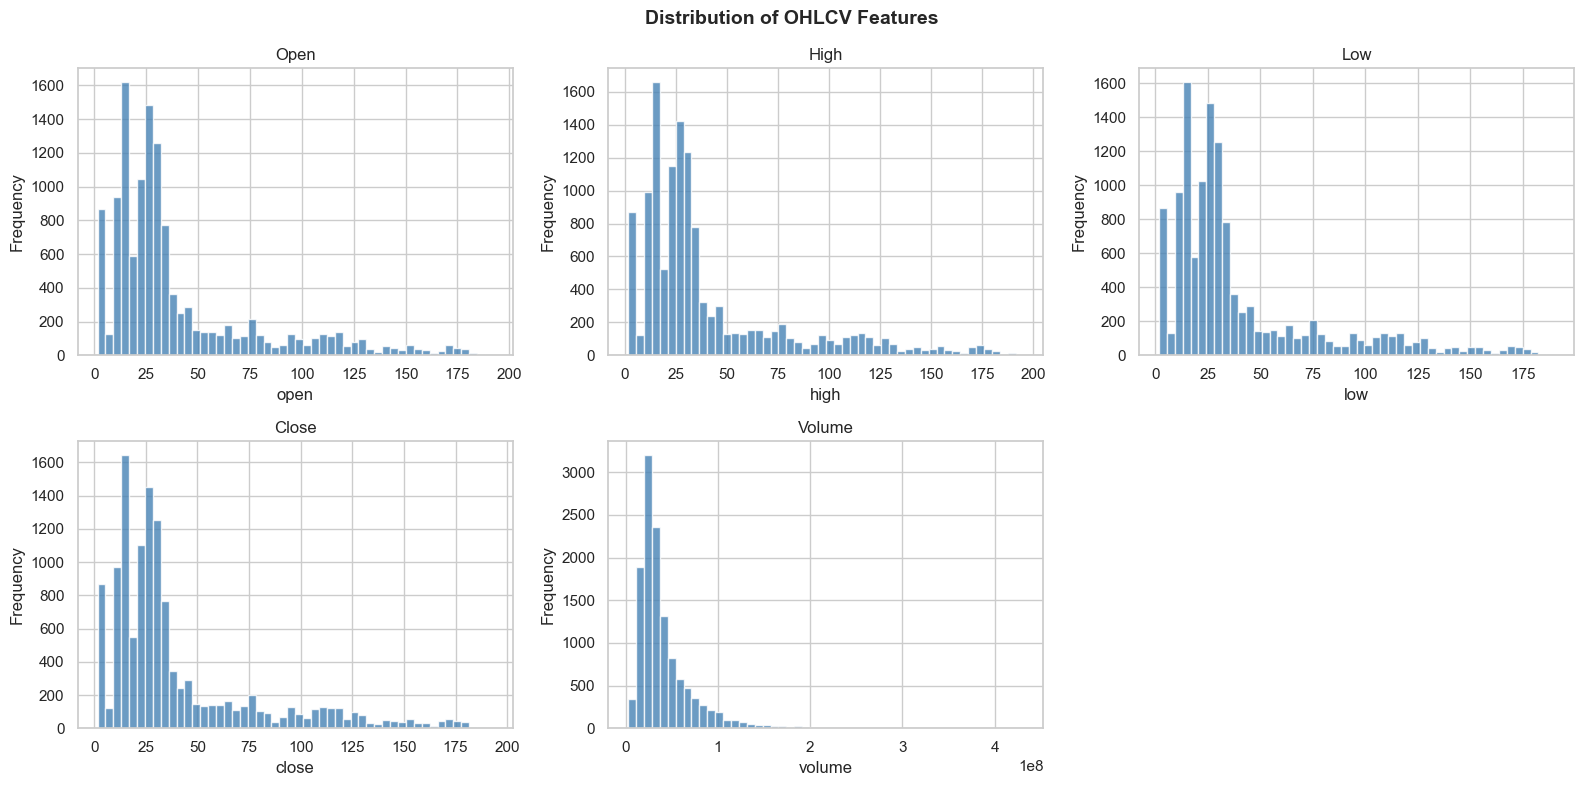

In [9]:
# Step 2.2 - Distribution Plots: Histograms of OHLCV features

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution of OHLCV Features', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), ['open','high','low','close','volume']):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col.capitalize())
    ax.set_xlabel(col); ax.set_ylabel('Frequency')
axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eda_ohlcv_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

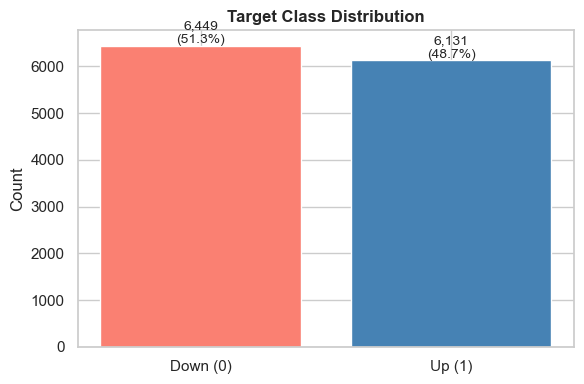

In [10]:
# Step 2.3 - Class Balance Bar Chart

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts()
ax.bar(['Down (0)','Up (1)'], counts.values, color=['salmon','steelblue'], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eda_class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

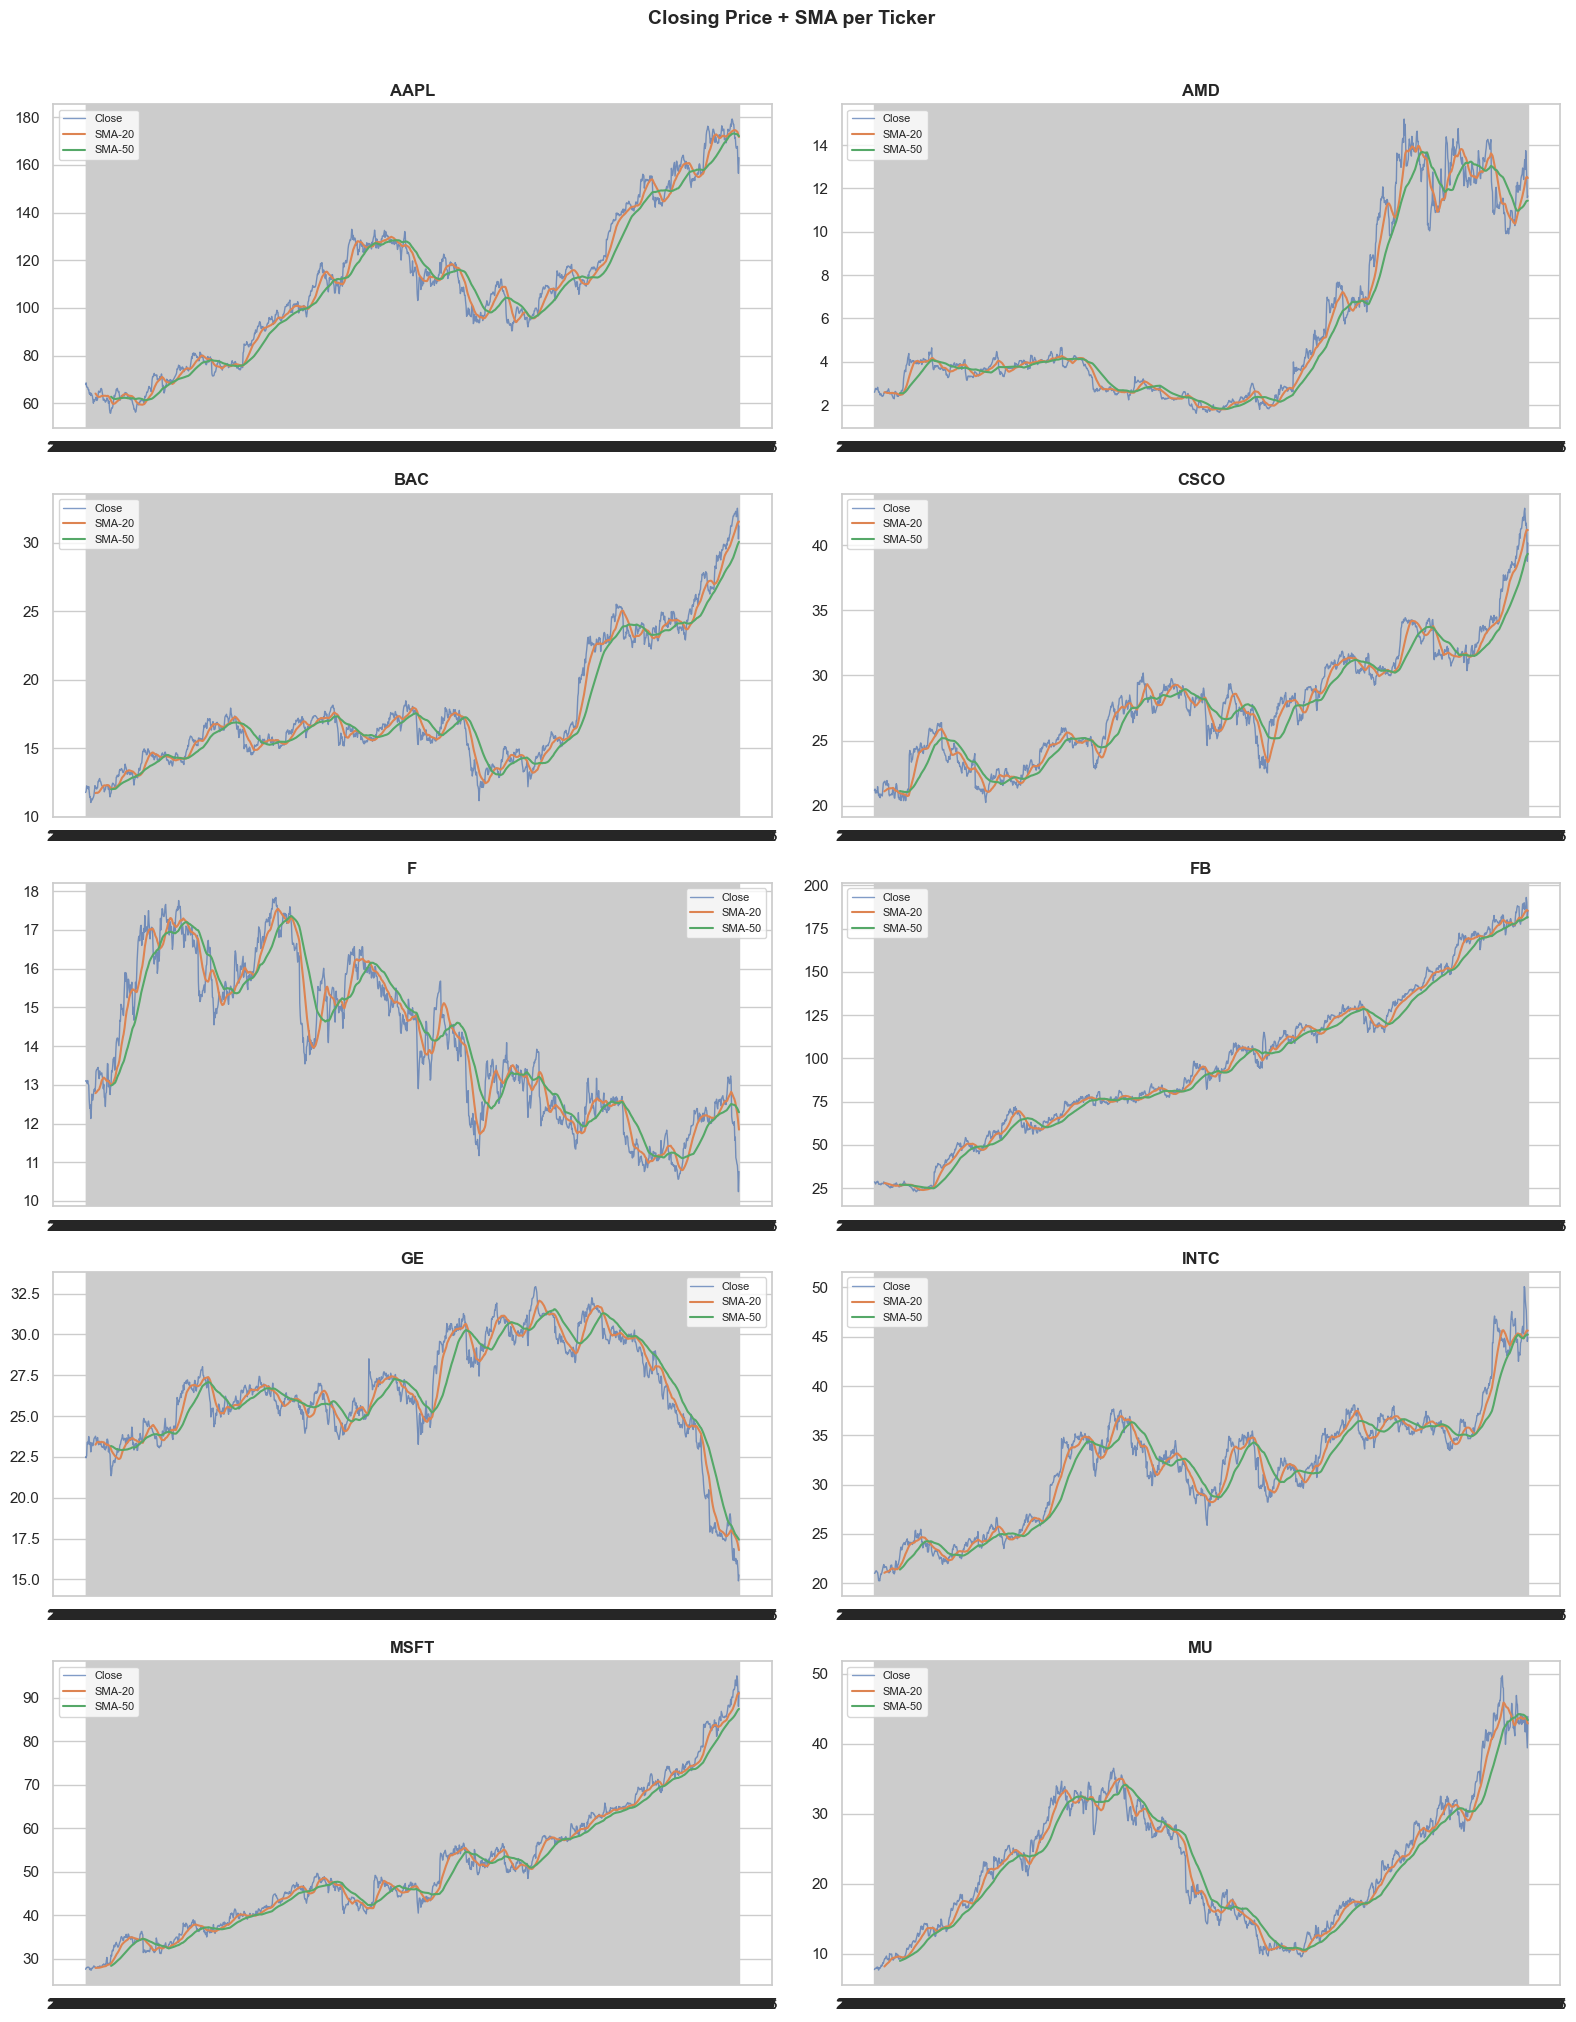

In [11]:
# Step 2.4 - Closing Price + 20/50-day SMA per Ticker

tickers = sorted(df['Name'].unique())
ncols   = 2
nrows   = (len(tickers) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = np.array(axes).flatten()

for idx, ticker in enumerate(tickers):
    sub = df[df['Name'] == ticker].copy()
    sub['sma_20'] = sub['close'].rolling(20).mean()
    sub['sma_50'] = sub['close'].rolling(50).mean()
    axes[idx].plot(sub['date'], sub['close'],   label='Close',  alpha=0.7, lw=1)
    axes[idx].plot(sub['date'], sub['sma_20'],  label='SMA-20', lw=1.5)
    axes[idx].plot(sub['date'], sub['sma_50'],  label='SMA-50', lw=1.5)
    axes[idx].set_title(ticker, fontweight='bold')
    axes[idx].legend(fontsize=8)

for i in range(len(tickers), len(axes)): axes[i].set_visible(False)

fig.suptitle('Closing Price + SMA per Ticker', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eda_timeseries_sma.png'), dpi=150, bbox_inches='tight')
plt.show()

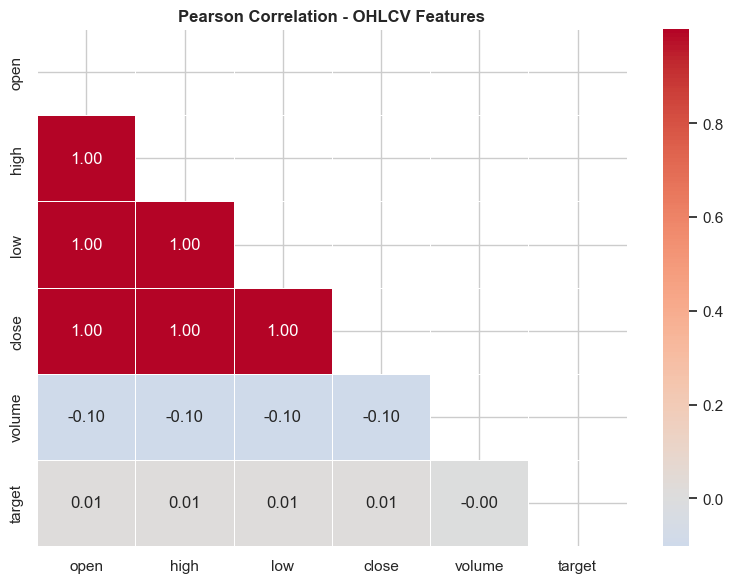

Highly correlated pairs (|r| > 0.90):
  high -- open: 1.000
  high -- low: 1.000
  low -- open: 1.000
  close -- open: 1.000
  close -- high: 1.000
  close -- low: 1.000


In [12]:
# Step 2.5 - Pearson Correlation Heatmap

corr = df[['open','high','low','close','volume','target']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Pearson Correlation - OHLCV Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eda_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Highly correlated pairs (|r| > 0.90):')
for c1 in corr.columns:
    for c2 in corr.columns:
        if c1 < c2 and abs(corr.loc[c1, c2]) > 0.90:
            print(f'  {c1} -- {c2}: {corr.loc[c1,c2]:.3f}')

In [13]:
# Step 2.6 - ADF Stationarity Test on Close Price (3 tickers)

rep_tickers = sorted(df['Name'].unique())[:3]
print('ADF Stationarity Test - Close Price')
print('-' * 55)
for ticker in rep_tickers:
    series = df[df['Name'] == ticker]['close'].dropna().values
    stat, pval = adfuller(series)[:2]
    status = 'STATIONARY' if pval < 0.05 else 'NON-STATIONARY'
    print(f'{ticker:8s} | ADF: {stat:8.3f} | p-value: {pval:.4f} | {status}')

ADF Stationarity Test - Close Price
-------------------------------------------------------
AAPL     | ADF:   -0.554 | p-value: 0.8811 | NON-STATIONARY
AMD      | ADF:   -0.396 | p-value: 0.9107 | NON-STATIONARY
BAC      | ADF:    0.702 | p-value: 0.9899 | NON-STATIONARY


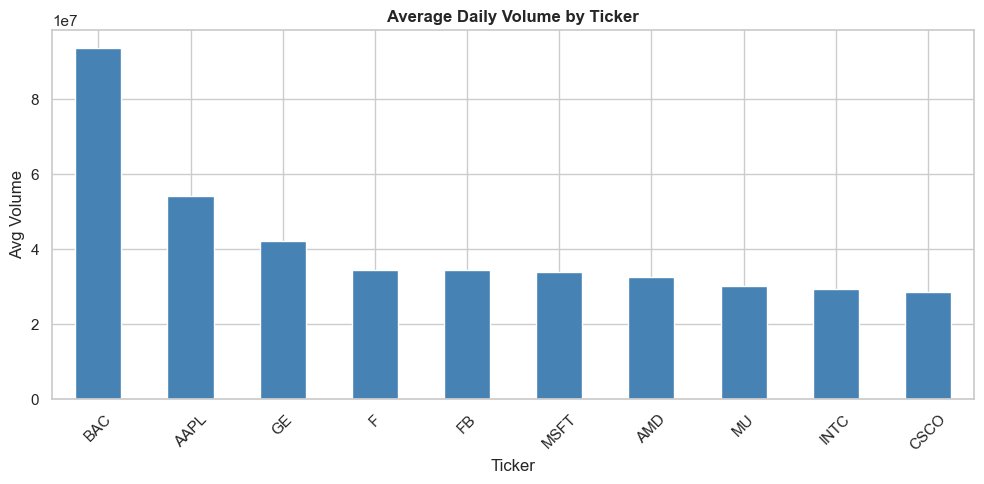

No low-volume tickers (all median volume >= 1000).


In [14]:
# Step 2.7 - Average Daily Volume by Ticker

avg_vol = df.groupby('Name')['volume'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
avg_vol.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Daily Volume by Ticker', fontweight='bold')
ax.set_xlabel('Ticker'); ax.set_ylabel('Avg Volume')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eda_avg_volume.png'), dpi=150, bbox_inches='tight')
plt.show()

low_vol = df.groupby('Name')['volume'].median()
low_vol = low_vol[low_vol < 1000]
if len(low_vol): print(f'Low-volume tickers: {low_vol.index.tolist()}')
else: print('No low-volume tickers (all median volume >= 1000).')

In [15]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'target'], dtype='str')

## Section 3 - Feature Engineering

In [16]:
print('=' * 60)
print('=== STEP 3: FEATURE ENGINEERING ===')
print('=' * 60)

df = pd.read_csv(os.path.join(output_dir, 'processed_stocks.csv'))
df = df.sort_values(['Name','date']).reset_index(drop=True)
print(f'Shape: {df.shape}')
df.head()

=== STEP 3: FEATURE ENGINEERING ===
Shape: (12580, 8)


,date,open,high,low,close,volume,Name,target
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,1
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,0
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,0
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,0
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,0


In [17]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'target'], dtype='str')

In [18]:
# Step 3.2 - Compute Technical Indicators per Ticker (ta library)

def add_indicators(grp):
    grp = grp.copy()
    c, h, l, v = grp["close"], grp["high"], grp["low"], grp["volume"]

    # Trend
    grp["SMA_20"] = ta.trend.sma_indicator(c, window=20)
    grp["SMA_50"] = ta.trend.sma_indicator(c, window=50)
    grp["EMA_12"] = ta.trend.ema_indicator(c, window=12)
    grp["EMA_26"] = ta.trend.ema_indicator(c, window=26)
    macd = ta.trend.MACD(c, window_slow=26, window_fast=12, window_sign=9)
    grp["MACD"]        = macd.macd()
    grp["MACD_signal"] = macd.macd_signal()
    grp["MACD_diff"]   = macd.macd_diff()

    # Momentum
    grp["RSI_14"] = ta.momentum.rsi(c, window=14)
    stoch = ta.momentum.StochasticOscillator(h, l, c, window=14, smooth_window=3)
    grp["Stoch_k"] = stoch.stoch()
    grp["Stoch_d"] = stoch.stoch_signal()
    grp["ROC_10"]  = ta.momentum.roc(c, window=10)

    # Volatility
    bb = ta.volatility.BollingerBands(c, window=20, window_dev=2)
    grp["BB_upper"] = bb.bollinger_hband()
    grp["BB_lower"] = bb.bollinger_lband()
    grp["BB_width"] = (bb.bollinger_hband() - bb.bollinger_lband()) / bb.bollinger_mavg()
    grp["ATR_14"]   = ta.volatility.average_true_range(h, l, c, window=14)

    # Volume
    grp["OBV"]           = ta.volume.on_balance_volume(c, v)
    grp["Volume_SMA_20"] = ta.trend.sma_indicator(v.astype(float), window=20)
    grp["Volume_ratio"]  = v / grp["Volume_SMA_20"].replace(0, np.nan)

    return grp

# Iterate over unique tickers directly -- avoids groupby key-column dropping
dfs = []
for ticker in sorted(df["Name"].unique()):
    grp = df[df["Name"] == ticker].copy()
    dfs.append(add_indicators(grp))

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(["Name", "date"]).reset_index(drop=True)
print(f"Shape after indicators : {df.shape}")
print(f"Name column present    : {chr(39)}Name{chr(39)} in df.columns => {chr(123)}{chr(39)}Name{chr(39)} in df.columns{chr(125)}")

Shape after indicators : (12580, 26)
Name column present    : 'Name' in df.columns => {'Name' in df.columns}


In [19]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'target',
       'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal',
       'MACD_diff', 'RSI_14', 'Stoch_k', 'Stoch_d', 'ROC_10', 'BB_upper',
       'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'Volume_SMA_20',
       'Volume_ratio'],
      dtype='str')

In [20]:
# Step 3.3 - Lag Features and Price-Derived Features (per ticker)

def add_lag_features(grp):
    grp = grp.copy()
    c = grp["close"]
    grp["close_lag_1"]    = c.shift(1)
    grp["close_lag_2"]    = c.shift(2)
    grp["close_lag_3"]    = c.shift(3)
    grp["close_lag_5"]    = c.shift(5)
    grp["daily_return"]   = (c - c.shift(1)) / c.shift(1)
    grp["high_low_range"] = (grp["high"] - grp["low"]) / c
    grp["open_close_gap"] = (c - grp["open"]) / grp["open"]
    return grp

# Iterate over unique tickers directly -- avoids groupby key-column dropping
dfs = []
for ticker in sorted(df["Name"].unique()):
    grp = df[df["Name"] == ticker].copy()
    dfs.append(add_lag_features(grp))

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(["Name", "date"]).reset_index(drop=True)

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows dropped (NaN warm-up): {before - len(df)}")
print(f"Final shape              : {df.shape}")
print(f"Name column present      : {chr(39)}Name{chr(39)} in df.columns")

base_cols = ["date","open","high","low","close","volume","Name","target"]
feat_cols  = [col for col in df.columns if col not in base_cols]
print(f"Engineered features ({len(feat_cols)}): {feat_cols}")

Rows dropped (NaN warm-up): 490
Final shape              : (12090, 33)
Name column present      : 'Name' in df.columns
Engineered features (25): ['SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'MACD_diff', 'RSI_14', 'Stoch_k', 'Stoch_d', 'ROC_10', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'Volume_SMA_20', 'Volume_ratio', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5', 'daily_return', 'high_low_range', 'open_close_gap']


In [21]:
# Step 3.4 - Save feature-engineered dataset

feat_path = os.path.join(output_dir, 'features_stocks.csv')
df.to_csv(feat_path, index=False)
print(f'Saved: {feat_path}  |  Shape: {df.shape}')
df.head()

Saved: ..\..\output\features_stocks.csv  |  Shape: (12090, 33)


,date,open,high,low,close,volume,Name,target,SMA_20,SMA_50,...,OBV,Volume_SMA_20,Volume_ratio,close_lag_1,close_lag_2,close_lag_3,close_lag_5,daily_return,high_low_range,open_close_gap
0,2013-04-22,56.0914,57.4571,55.8964,56.9528,107338322,AAPL,1,61.030070,62.747386,...,-919658593,1.050822e+08,1.021470,55.7899,56.0071,57.5428,59.9785,0.020844,0.027403,0.015357
1,2013-04-23,57.7128,58.3401,56.9728,58.0185,160760747,AAPL,0,60.619715,62.550672,...,-758897846,1.068666e+08,1.504312,56.9528,55.7899,56.0071,60.8914,0.018712,0.023567,0.005297
2,2013-04-24,56.2199,59.3214,56.0714,57.9231,242387530,AAPL,1,60.222045,62.337906,...,-1001285376,1.153146e+08,2.101968,58.0185,56.9528,55.7899,57.5428,-0.001644,0.056109,0.030295
3,2013-04-25,58.7464,59.1342,58.1428,58.3399,95984896,AAPL,1,59.909900,62.167848,...,-905300480,1.160211e+08,0.827305,57.9231,58.0185,56.9528,56.0071,0.007196,0.016994,-0.006920
4,2013-04-26,58.5442,59.8241,58.3214,59.6007,191006032,AAPL,1,59.728080,62.025550,...,-714294448,1.200365e+08,1.591233,58.3399,57.9231,58.0185,55.7899,0.021611,0.025213,0.018046


## Section 4 - Preprocessing & Train/Test Split

In [22]:
print('=' * 60)
print('=== STEP 4: PREPROCESSING & TRAIN/TEST SPLIT ===')
print('=' * 60)

# Drop raw OHLCV columns, keep engineered features only
drop_cols    = ['open','high','low','close','volume','Name','target','date']
feature_cols = [c for c in df.columns if c not in drop_cols]

X     = df[feature_cols].values
y     = df['target'].values
dates = df['date'].values

print(f'Feature matrix X : {X.shape}')
print(f'Response vector y: {y.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

=== STEP 4: PREPROCESSING & TRAIN/TEST SPLIT ===
Feature matrix X : (12090, 25)
Response vector y: (12090,)
Features (25): ['SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'MACD_diff', 'RSI_14', 'Stoch_k', 'Stoch_d', 'ROC_10', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'Volume_SMA_20', 'Volume_ratio', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5', 'daily_return', 'high_low_range', 'open_close_gap']


In [23]:
# Step 4.2 - Time-Aware 80/20 Split (no shuffle -- prevents data leakage)

# Compute the 80th-percentile cutoff date by index position.
# Avoids np.percentile(interpolation=) which was deprecated in NumPy 1.22+
# and is unreliable on datetime64 arrays across NumPy versions.
unique_dates = np.sort(np.unique(dates))
cutoff_idx   = int(len(unique_dates) * 0.8)
cutoff_date  = unique_dates[cutoff_idx]
print(f"Cutoff date : {pd.Timestamp(cutoff_date).date()}")
print(f"Train dates : up to  {pd.Timestamp(unique_dates[cutoff_idx - 1]).date()}")
print(f"Test  dates : from   {pd.Timestamp(unique_dates[cutoff_idx]).date()}")

X_train, X_test = X[dates <= cutoff_date], X[dates > cutoff_date]
y_train, y_test = y[dates <= cutoff_date], y[dates > cutoff_date]

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"Class balance -- Train: {y_train.mean():.2%}  Test: {y_test.mean():.2%}")

# StandardScaler: fit on train only, transform both
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Save splits and scaler
pd.DataFrame(X_train, columns=feature_cols).to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
pd.DataFrame(X_test,  columns=feature_cols).to_csv(os.path.join(output_dir, "X_test.csv"),  index=False)
pd.DataFrame({"target": y_train}).to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
pd.DataFrame({"target": y_test}).to_csv(os.path.join(output_dir,  "y_test.csv"),  index=False)
joblib.dump(scaler, os.path.join(output_dir, "scaler.pkl"))
print("Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv, scaler.pkl")

Cutoff date : 2017-02-22
Train dates : up to  2017-02-21
Test  dates : from   2017-02-22
X_train: (9680, 25)  y_train: (9680,)
X_test : (2410, 25)   y_test : (2410,)
Class balance -- Train: 51.20%  Test: 51.91%
Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv, scaler.pkl


## Section 5 - Deep Learning Model Training & Validation

In [24]:
print('=' * 60)
print('=== STEP 5: DEEP LEARNING MODEL TRAINING ===')
print('=' * 60)

n_features = X_train.shape[1]
EPOCHS     = 100
BATCH_SIZE = 256
LOOKBACK   = 10   # time steps for sequence models

early_stop = EarlyStopping(
    monitor='val_auc', patience=10,
    restore_best_weights=True, mode='max'
)

trained_models   = {}   # stores trained model objects
training_history = {}   # stores Keras History objects

print(f'n_features : {n_features}')
print(f'X_train    : {X_train.shape}')
print(f'X_test     : {X_test.shape}')

=== STEP 5: DEEP LEARNING MODEL TRAINING ===
n_features : 25
X_train    : (9680, 25)
X_test     : (2410, 25)


In [25]:
# Helper: plot and save training vs validation loss and AUC curves

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{model_name} - Training History', fontweight='bold')
    axes[0].plot(history.history['loss'],    label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history.history['auc'],     label='Train AUC')
    axes[1].plot(history.history['val_auc'],  label='Val AUC')
    axes[1].set_title('ROC-AUC'); axes[1].legend()
    plt.tight_layout()
    save_path = os.path.join(output_dir, f'{model_name}_training_history.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

=== MODEL A: FEEDFORWARD NEURAL NETWORK (FNN) ===


Model: "FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.4991 - auc: 0.4994 - loss: 0.7964 - val_accuracy: 0.5007 - val_auc: 0.5054 - val_loss: 0.6930
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5094 - auc: 0.5128 - loss: 0.7430 - val_accuracy: 0.5028 - val_auc: 0.5038 - val_loss: 0.6928
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4989 - auc: 0.5032 - loss: 0.7297 - val_accuracy: 0.5034 - val_auc: 0.5150 - val_loss: 0.6925
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5128 - auc: 0.5102 - loss: 0.7216 - val_accuracy: 0.5034 - val_auc: 0.5382 - val_loss: 0.6915
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5084 - auc: 0.5118 - loss: 0.7154 - val_accuracy: 0.5179 - val_auc: 0.5349 - val_loss: 0.6913
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5216 - auc: 0.5253 - loss: 0.7072 - val_accuracy: 0.5076 - val_auc: 0.5332 - val_loss: 0.6913
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

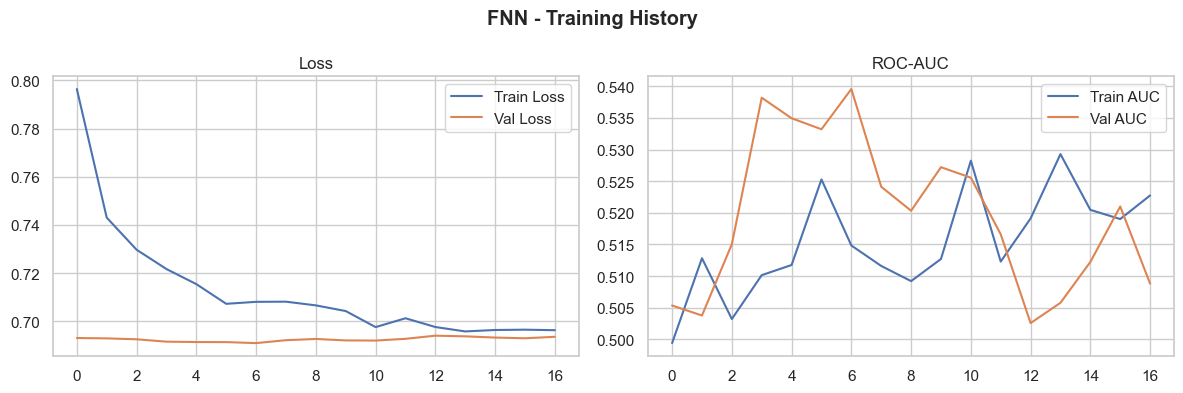

Saved: ..\..\output\FNN_training_history.png
Model A (FNN) trained successfully.


In [26]:
# ── MODEL A: Feedforward Neural Network (FNN / MLP) ──
# Input: (n_samples, n_features) - no sequence reshaping

print('=== MODEL A: FEEDFORWARD NEURAL NETWORK (FNN) ===')
try:
    tf.random.set_seed(42)
    inp = keras.Input(shape=(n_features,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model_fnn = keras.Model(inp, out, name='FNN')
    model_fnn.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    model_fnn.summary()
    hist_fnn = model_fnn.fit(
        X_train, y_train, validation_split=0.15,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=1
    )
    trained_models['FNN']   = model_fnn
    training_history['FNN'] = hist_fnn
    plot_history(hist_fnn, 'FNN')
    print('Model A (FNN) trained successfully.')
except Exception as e:
    print(f'ERROR training FNN: {e}')

=== MODEL B: 1D-CNN ===


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 25, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4954 - auc: 0.4903 - loss: 0.6944 - val_accuracy: 0.5110 - val_auc: 0.5123 - val_loss: 0.6927
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5122 - auc: 0.4909 - loss: 0.6937 - val_accuracy: 0.5110 - val_auc: 0.5058 - val_loss: 0.6929
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5119 - auc: 0.5034 - loss: 0.6932 - val_accuracy: 0.5103 - val_auc: 0.5092 - val_loss: 0.6928
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5113 - auc: 0.4903 - loss: 0.6933 - val_accuracy: 0.5110 - val_auc: 0.5090 - val_loss: 0.6928
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5097 - auc: 0.4920 - loss: 0.6930 - val_accuracy: 0.5110 - val_auc: 0.4994 - val_loss: 0.6929
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5109 - auc: 0.4971 - loss: 0.6931 - val_accuracy: 0.5117 - val_auc: 0.5067 - val_loss: 0.6929
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0

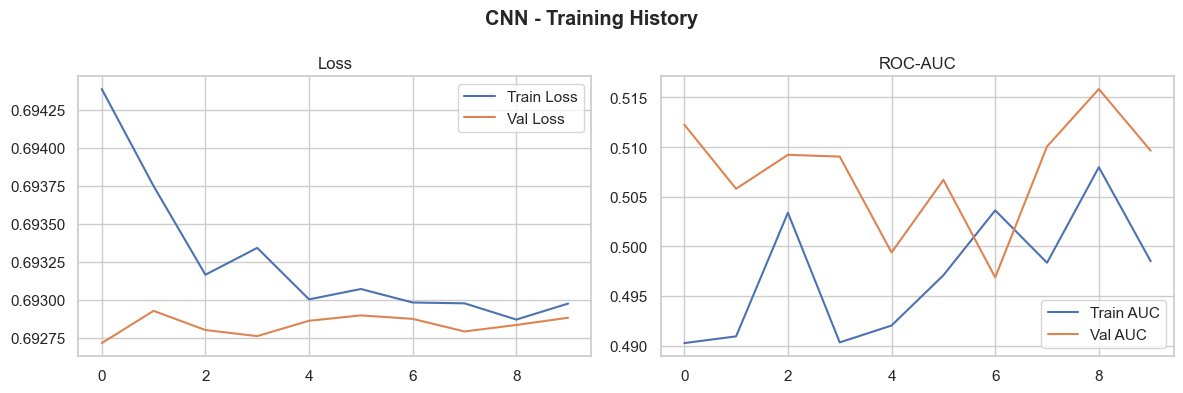

Saved: ..\..\output\CNN_training_history.png
Model B (1D-CNN) trained successfully.


In [27]:
# ── MODEL B: 1D Convolutional Neural Network (1D-CNN) ──
# Reshape X to (n_samples, n_features, 1): features treated as 1D sequence

print('=== MODEL B: 1D-CNN ===')
try:
    tf.random.set_seed(42)
    X_train_cnn = X_train.reshape(X_train.shape[0], n_features, 1)
    X_test_cnn  = X_test.reshape(X_test.shape[0],   n_features, 1)

    inp = keras.Input(shape=(n_features, 1))
    x   = layers.Conv1D(64,  kernel_size=3, activation='relu', padding='same')(inp)
    x   = layers.MaxPooling1D(pool_size=2)(x)
    x   = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model_cnn = keras.Model(inp, out, name='CNN')
    model_cnn.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    model_cnn.summary()
    hist_cnn = model_cnn.fit(
        X_train_cnn, y_train, validation_split=0.15,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=1
    )
    trained_models['CNN']   = model_cnn
    training_history['CNN'] = hist_cnn
    plot_history(hist_cnn, 'CNN')
    print('Model B (1D-CNN) trained successfully.')
except Exception as e:
    print(f'ERROR training 1D-CNN: {e}')

In [28]:
# Step 5.4 - Build Sliding-Window Sequences (lookback=10) for LSTM/GRU/Transformer

def build_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq_train, y_seq_train = build_sequences(X_train, y_train, LOOKBACK)
X_seq_test,  y_seq_test  = build_sequences(X_test,  y_test,  LOOKBACK)

print(f'X_seq_train: {X_seq_train.shape}  (samples, lookback={LOOKBACK}, features={n_features})')
print(f'X_seq_test : {X_seq_test.shape}')

X_seq_train: (9670, 10, 25)  (samples, lookback=10, features=25)
X_seq_test : (2400, 10, 25)


=== MODEL C: LSTM ===


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 25)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 128)        │        78,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,369 (509.25 KB)

 Trainable params: 130,369 (509.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.5059 - auc: 0.5050 - loss: 0.6954 - val_accuracy: 0.4976 - val_auc: 0.5006 - val_loss: 0.6949
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5071 - auc: 0.5062 - loss: 0.6949 - val_accuracy: 0.5017 - val_auc: 0.5126 - val_loss: 0.6934
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5203 - auc: 0.5226 - loss: 0.6928 - val_accuracy: 0.4914 - val_auc: 0.5045 - val_loss: 0.6942
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5166 - auc: 0.5239 - loss: 0.6924 - val_accuracy: 0.4983 - val_auc: 0.4975 - val_loss: 0.6947
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5296 - auc: 0.5380 - loss: 0.6909 - val_accuracy: 0.4928 - val_auc: 0.4929 - val_loss: 0.6963
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5155 - auc: 0.5250 - loss: 0.6928 - val_accuracy: 0.4969 - val_auc: 0.4913 - val_loss: 0.6963
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2

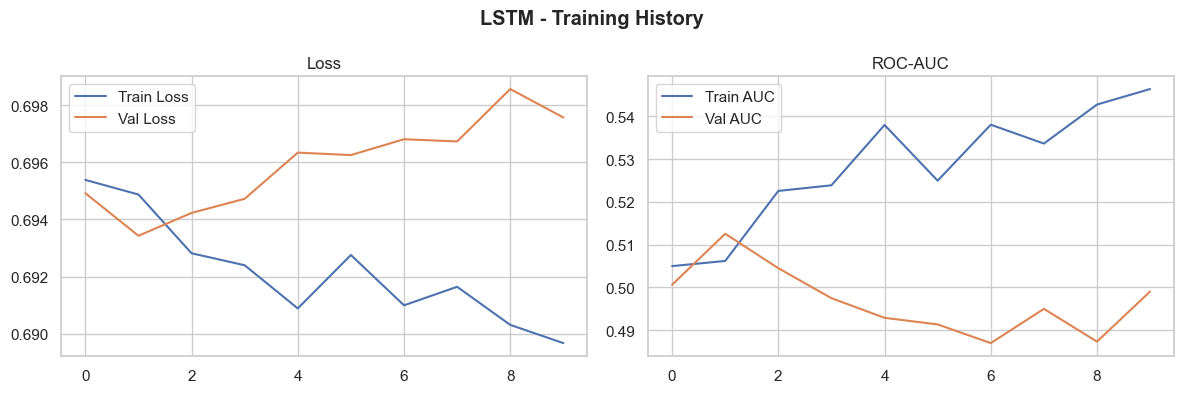

Saved: ..\..\output\LSTM_training_history.png
Model C (LSTM) trained successfully.


In [29]:
# ── MODEL C: Long Short-Term Memory (LSTM) ──

print('=== MODEL C: LSTM ===')
try:
    tf.random.set_seed(42)
    inp = keras.Input(shape=(LOOKBACK, n_features))
    x   = layers.LSTM(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(64, return_sequences=False)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model_lstm = keras.Model(inp, out, name='LSTM')
    model_lstm.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    model_lstm.summary()
    hist_lstm = model_lstm.fit(
        X_seq_train, y_seq_train, validation_split=0.15,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=1
    )
    trained_models['LSTM']   = model_lstm
    training_history['LSTM'] = hist_lstm
    plot_history(hist_lstm, 'LSTM')
    print('Model C (LSTM) trained successfully.')
except Exception as e:
    print(f'ERROR training LSTM: {e}')

=== MODEL D: GRU ===


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 25)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 10, 128)        │        59,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,881 (386.25 KB)

 Trainable params: 98,881 (386.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.5029 - auc: 0.5037 - loss: 0.7026 - val_accuracy: 0.4962 - val_auc: 0.4903 - val_loss: 0.6959
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5059 - auc: 0.5051 - loss: 0.6983 - val_accuracy: 0.4962 - val_auc: 0.5025 - val_loss: 0.6988
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5063 - auc: 0.5078 - loss: 0.6966 - val_accuracy: 0.5031 - val_auc: 0.5115 - val_loss: 0.6932
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5153 - auc: 0.5173 - loss: 0.6945 - val_accuracy: 0.4948 - val_auc: 0.5059 - val_loss: 0.6947
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5187 - auc: 0.5190 - loss: 0.6943 - val_accuracy: 0.5079 - val_auc: 0.5044 - val_loss: 0.6942
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5175 - auc: 0.5266 - loss: 0.6924 - val_accuracy: 0.4941 - val_auc: 0.4976 - val_loss: 0.6949
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2

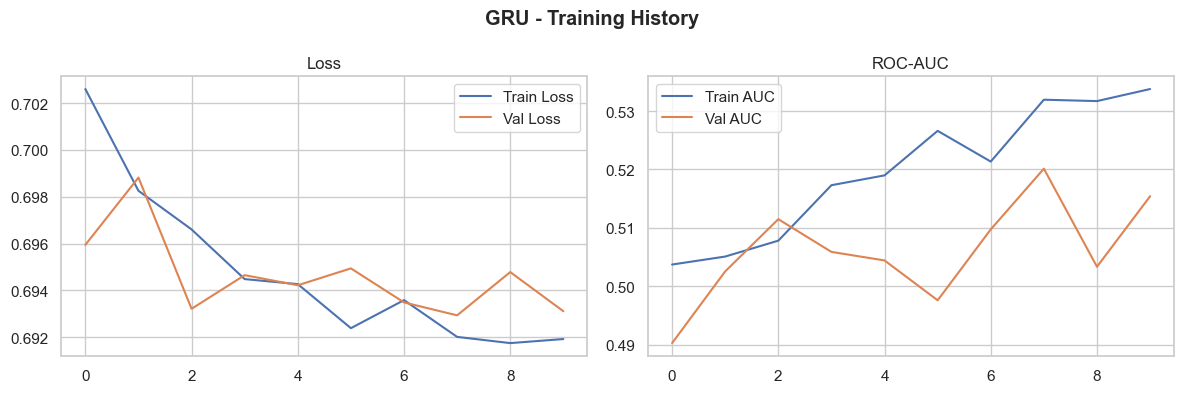

Saved: ..\..\output\GRU_training_history.png
Model D (GRU) trained successfully.


In [30]:
# ── MODEL D: Gated Recurrent Unit (GRU) ──

print('=== MODEL D: GRU ===')
try:
    tf.random.set_seed(42)
    inp = keras.Input(shape=(LOOKBACK, n_features))
    x   = layers.GRU(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.GRU(64, return_sequences=False)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model_gru = keras.Model(inp, out, name='GRU')
    model_gru.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    model_gru.summary()
    hist_gru = model_gru.fit(
        X_seq_train, y_seq_train, validation_split=0.15,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=1
    )
    trained_models['GRU']   = model_gru
    training_history['GRU'] = hist_gru
    plot_history(hist_gru, 'GRU')
    print('Model D (GRU) trained successfully.')
except Exception as e:
    print(f'ERROR training GRU: {e}')

=== MODEL E: TRANSFORMER ENCODER ===


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 10, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 25)    │     13,209 │ input_layer_4[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 25)    │          0 │ input_layer_4[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 25)    │         50 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 10, 64)    │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 10, 25)    │      1,625 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 25)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 25)    │         50 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 25)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      1,664 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,327 (71.59 KB)

 Trainable params: 18,327 (71.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.5002 - auc: 0.5065 - loss: 0.7124 - val_accuracy: 0.5072 - val_auc: 0.5021 - val_loss: 0.6977
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5029 - auc: 0.5019 - loss: 0.7045 - val_accuracy: 0.4948 - val_auc: 0.4984 - val_loss: 0.6967
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5071 - auc: 0.5132 - loss: 0.6980 - val_accuracy: 0.5003 - val_auc: 0.5098 - val_loss: 0.6941
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5221 - auc: 0.5235 - loss: 0.6949 - val_accuracy: 0.5045 - val_auc: 0.5137 - val_loss: 0.6935
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5248 - auc: 0.5312 - loss: 0.6926 - val_accuracy: 0.4941 - val_auc: 0.5156 - val_loss: 0.6933
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5171 - auc: 0.5221 - loss: 0.6937 - val_accuracy: 0.4976 - val_auc: 0.5096 - val_loss: 0.6937
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1

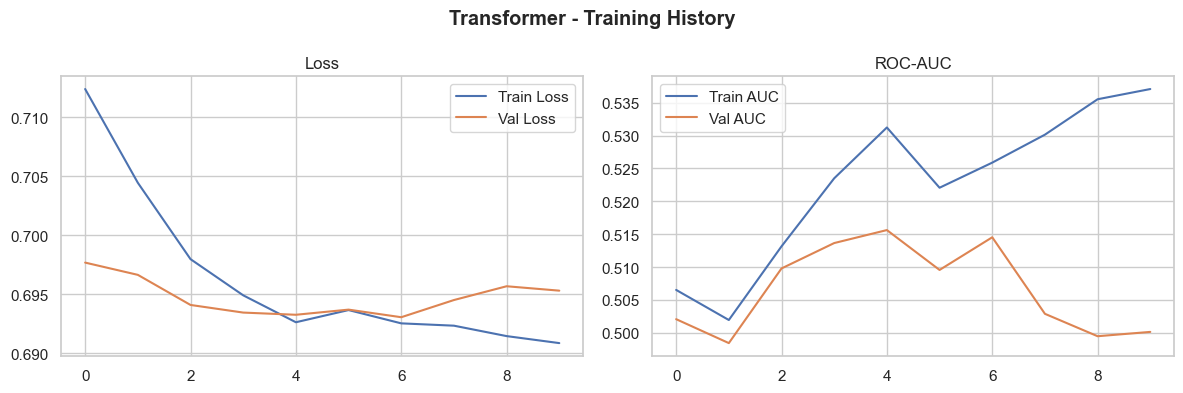

Saved: ..\..\output\Transformer_training_history.png
Model E (Transformer) trained successfully.


In [31]:
# ── MODEL E: Transformer Encoder ──
# Self-attention block + FFN block + GlobalAveragePooling + classifier head

print('=== MODEL E: TRANSFORMER ENCODER ===')
try:
    tf.random.set_seed(42)
    inp     = keras.Input(shape=(LOOKBACK, n_features))
    attn    = layers.MultiHeadAttention(num_heads=4, key_dim=32)(inp, inp)
    x       = layers.Add()([inp, attn])
    x       = layers.LayerNormalization()(x)
    ff      = layers.Dense(64, activation='relu')(x)
    ff      = layers.Dense(n_features)(ff)
    x       = layers.Add()([x, ff])
    x       = layers.LayerNormalization()(x)
    x       = layers.GlobalAveragePooling1D()(x)
    x       = layers.Dense(64, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    out     = layers.Dense(1, activation='sigmoid')(x)
    model_transformer = keras.Model(inp, out, name='Transformer')
    model_transformer.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    model_transformer.summary()
    hist_transformer = model_transformer.fit(
        X_seq_train, y_seq_train, validation_split=0.15,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=1
    )
    trained_models['Transformer']   = model_transformer
    training_history['Transformer'] = hist_transformer
    plot_history(hist_transformer, 'Transformer')
    print('Model E (Transformer) trained successfully.')
except Exception as e:
    print(f'ERROR training Transformer: {e}')

## Section 6 - Model Evaluation

In [32]:
print('=' * 60)
print('=== STEP 6: MODEL EVALUATION ===')
print('=' * 60)

# Map each model to its correct test arrays
model_test_data = {
    'FNN':         (X_test,      y_test),
    'CNN':         (X_test_cnn,  y_test),
    'LSTM':        (X_seq_test,  y_seq_test),
    'GRU':         (X_seq_test,  y_seq_test),
    'Transformer': (X_seq_test,  y_seq_test),
}

def evaluate_model(model, X_te, y_te):
    y_proba = model.predict(X_te, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    return {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred, zero_division=0),
        'F1':        f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_te, y_proba),
        'y_proba':   y_proba,
        'y_pred':    y_pred,
    }

results = {}
for name, model in trained_models.items():
    X_te, y_te = model_test_data[name]
    results[name] = evaluate_model(model, X_te, y_te)
    r = results[name]
    print(f'{name:15s} | Acc: {r["Accuracy"]:.4f} | F1: {r["F1"]:.4f} | AUC: {r["ROC-AUC"]:.4f}')

=== STEP 6: MODEL EVALUATION ===
FNN             | Acc: 0.4983 | F1: 0.6027 | AUC: 0.4840
CNN             | Acc: 0.5207 | F1: 0.6835 | AUC: 0.5006
LSTM            | Acc: 0.4938 | F1: 0.5518 | AUC: 0.4994
GRU             | Acc: 0.5042 | F1: 0.6001 | AUC: 0.4988
Transformer     | Acc: 0.5058 | F1: 0.5374 | AUC: 0.4982


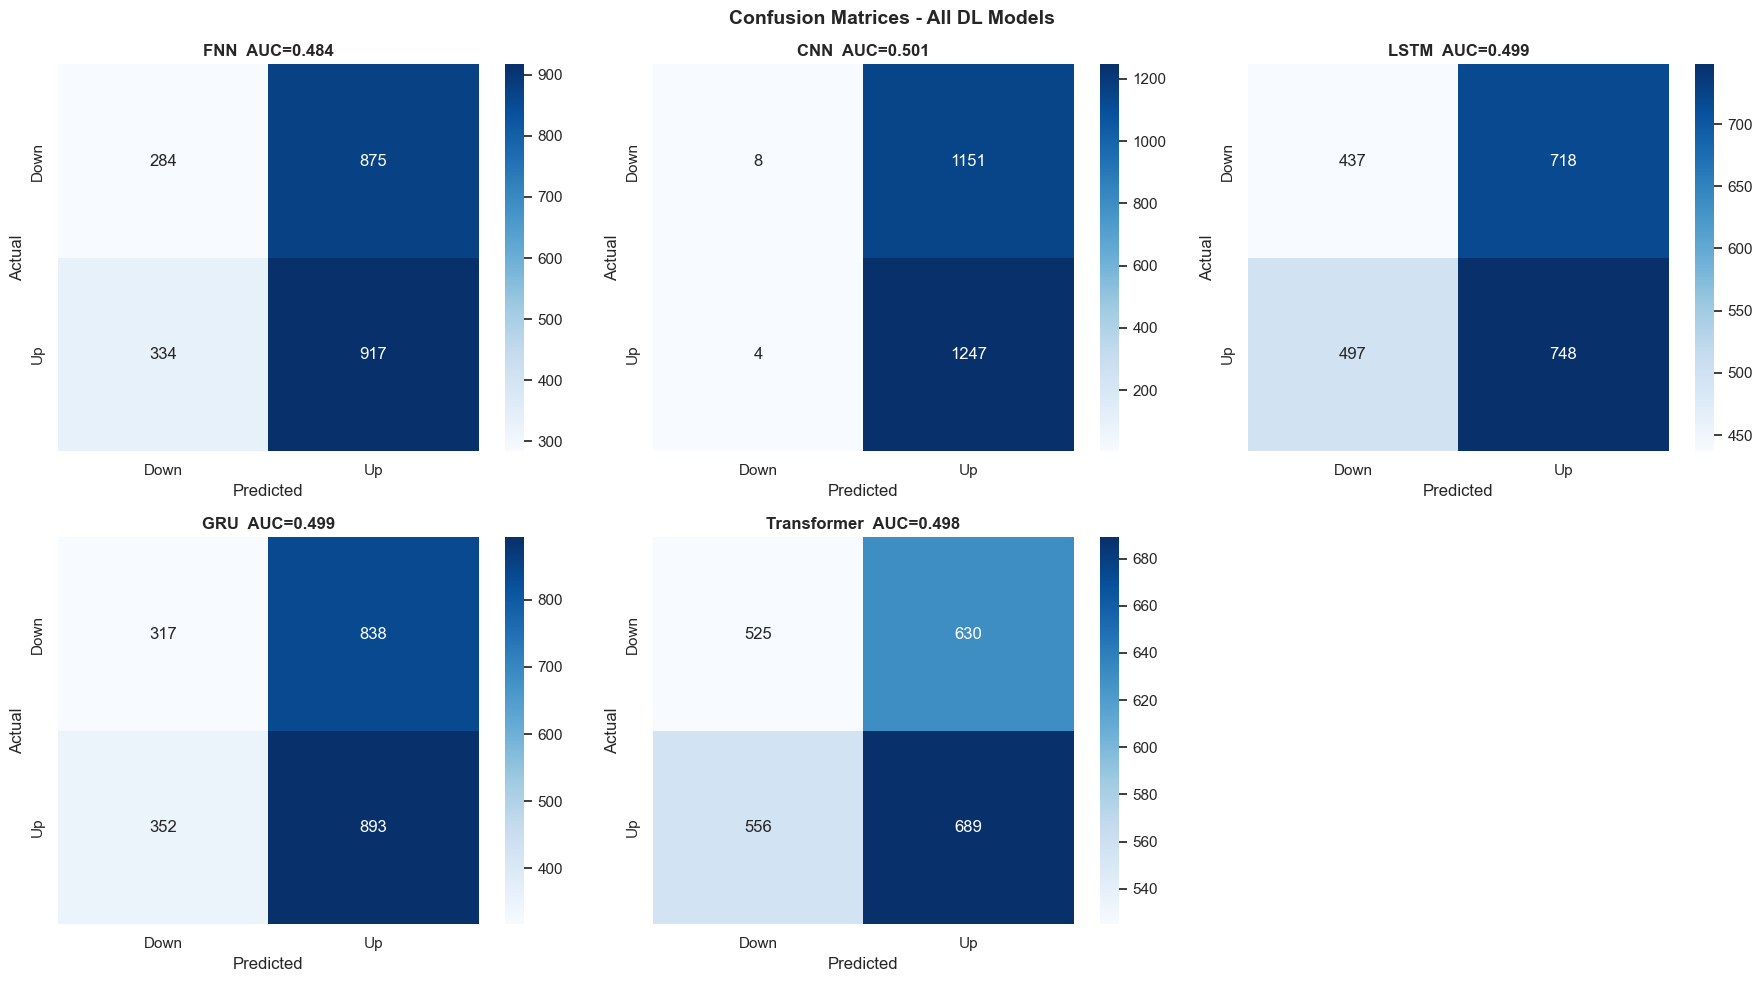

In [33]:
# Step 6.2 - Confusion Matrices for All Models

n_m   = len(trained_models)
ncols = min(3, n_m)
nrows = (n_m + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = np.array(axes).flatten()

for idx, (name, res) in enumerate(results.items()):
    _, y_te = model_test_data[name]
    cm = confusion_matrix(y_te, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    axes[idx].set_title(f'{name}  AUC={res["ROC-AUC"]:.3f}', fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
    # Save individual confusion matrix
    fig_i, ax_i = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_i,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax_i.set_title(f'{name} - Confusion Matrix', fontweight='bold')
    fig_i.tight_layout()
    fig_i.savefig(os.path.join(output_dir, f'{name}_confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.close(fig_i)

for i in range(n_m, len(axes)): axes[i].set_visible(False)
fig.suptitle('Confusion Matrices - All DL Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'all_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Step 6.3 - Consolidated Comparison Table (sorted by ROC-AUC desc)

comp_rows = [{'Model': n, 'Accuracy': round(r['Accuracy'],4),
              'Precision': round(r['Precision'],4), 'Recall': round(r['Recall'],4),
              'F1': round(r['F1'],4), 'ROC-AUC': round(r['ROC-AUC'],4)}
             for n, r in results.items()]

comp_df = pd.DataFrame(comp_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comp_df.to_csv(os.path.join(output_dir, 'dl_model_comparison.csv'), index=False)
print('Saved: dl_model_comparison.csv')
display(comp_df)

Saved: dl_model_comparison.csv


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,CNN,0.5207,0.5200,0.9968,0.6835,0.5006
1,LSTM,0.4938,0.5102,0.6008,0.5518,0.4994
2,GRU,0.5042,0.5159,0.7173,0.6001,0.4988
3,Transformer,0.5058,0.5224,0.5534,0.5374,0.4982
4,FNN,0.4983,0.5117,0.7330,0.6027,0.4840


## Section 7 - Hyperparameter Tuning (Best Model)

In [35]:
print('=' * 60)
print('=== STEP 7: HYPERPARAMETER TUNING ===')
print('=' * 60)

best_model_name = comp_df.iloc[0]['Model']
print(f'Best model: {best_model_name}  (Test ROC-AUC = {comp_df.iloc[0]["ROC-AUC"]})')

# Select train/test data for the best model
if best_model_name == 'FNN':
    X_tr_tune, y_tr_tune = X_train,     y_train
    X_te_tune, y_te_tune = X_test,       y_test
elif best_model_name == 'CNN':
    X_tr_tune, y_tr_tune = X_train_cnn,  y_train
    X_te_tune, y_te_tune = X_test_cnn,   y_test
else:
    X_tr_tune, y_tr_tune = X_seq_train,  y_seq_train
    X_te_tune, y_te_tune = X_seq_test,   y_seq_test

print(f'Tuning data -- Train: {X_tr_tune.shape}  Test: {X_te_tune.shape}')

=== STEP 7: HYPERPARAMETER TUNING ===
Best model: CNN  (Test ROC-AUC = 0.5006)
Tuning data -- Train: (9680, 25, 1)  Test: (2410, 25, 1)


In [36]:
# Keras-Tuner model builder functions for each architecture

def build_fnn_tuner(hp):
    u1 = hp.Choice('units1', [32, 64, 128, 256])
    u2 = hp.Choice('units2', [32, 64, 128])
    dr = hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4, 0.5])
    lr = hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
    inp = keras.Input(shape=(n_features,))
    x = layers.Dense(u1, activation='relu')(inp)
    x = layers.BatchNormalization()(x); x = layers.Dropout(dr)(x)
    x = layers.Dense(u2, activation='relu')(x); x = layers.Dropout(dr)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(lr), 'binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

def build_cnn_tuner(hp):
    f  = hp.Choice('filters', [32, 64, 128])
    dr = hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4, 0.5])
    lr = hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
    inp = keras.Input(shape=(n_features, 1))
    x = layers.Conv1D(f, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(f*2, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(dr)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(lr), 'binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

def build_lstm_tuner(hp):
    u1 = hp.Choice('units1', [64, 128, 256])
    u2 = hp.Choice('units2', [32, 64, 128])
    dr = hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4, 0.5])
    lr = hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
    inp = keras.Input(shape=(LOOKBACK, n_features))
    x = layers.LSTM(u1, return_sequences=True)(inp); x = layers.Dropout(dr)(x)
    x = layers.LSTM(u2)(x); x = layers.Dropout(dr)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(lr), 'binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

def build_gru_tuner(hp):
    u1 = hp.Choice('units1', [64, 128, 256])
    u2 = hp.Choice('units2', [32, 64, 128])
    dr = hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4, 0.5])
    lr = hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
    inp = keras.Input(shape=(LOOKBACK, n_features))
    x = layers.GRU(u1, return_sequences=True)(inp); x = layers.Dropout(dr)(x)
    x = layers.GRU(u2)(x); x = layers.Dropout(dr)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(lr), 'binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

def build_transformer_tuner(hp):
    nh = hp.Choice('num_heads', [2, 4, 8])
    kd = hp.Choice('key_dim', [16, 32, 64])
    ff = hp.Choice('ff_units', [32, 64, 128])
    dr = hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4, 0.5])
    lr = hp.Choice('lr', [1e-4, 5e-4, 1e-3, 5e-3])
    inp  = keras.Input(shape=(LOOKBACK, n_features))
    attn = layers.MultiHeadAttention(num_heads=nh, key_dim=kd)(inp, inp)
    x = layers.Add()([inp, attn]); x = layers.LayerNormalization()(x)
    f2 = layers.Dense(ff, activation='relu')(x); f2 = layers.Dense(n_features)(f2)
    x = layers.Add()([x, f2]); x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(dr)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(lr), 'binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

tuner_builders = {
    'FNN': build_fnn_tuner, 'CNN': build_cnn_tuner,
    'LSTM': build_lstm_tuner, 'GRU': build_gru_tuner,
    'Transformer': build_transformer_tuner
}
print(f'Builder ready for: {best_model_name}')

Builder ready for: CNN


In [37]:
# Step 7.3 - Run keras-tuner BayesianOptimization (20 trials)

try:
    tuner = kt.BayesianOptimization(
        tuner_builders[best_model_name],
        objective=kt.Objective("val_auc", direction="max"),
        max_trials=20,
        seed=42,
        directory=os.path.join(output_dir, "kt_tuner"),
        project_name=f"tune_{best_model_name}",
        overwrite=True   # avoids stale-directory errors on re-runs
    )

    tuner.search(
        X_tr_tune, y_tr_tune,
        epochs=50,
        batch_size=256,
        validation_split=0.15,
        callbacks=[EarlyStopping(monitor="val_auc", patience=5, mode="max",
                                 restore_best_weights=True)],
        verbose=0
    )

    best_hp    = tuner.get_best_hyperparameters(num_trials=1)[0]
    # Rebuild best model with best HPs and re-fit for full epochs
    best_tuned = tuner_builders[best_model_name](best_hp)
    best_tuned.fit(
        X_tr_tune, y_tr_tune,
        epochs=100,
        batch_size=256,
        validation_split=0.15,
        callbacks=[EarlyStopping(monitor="val_auc", patience=10, mode="max",
                                 restore_best_weights=True)],
        verbose=0
    )

    print(f"Best hyperparameters for {best_model_name}:")
    for k, v in best_hp.values.items():
        print(f"  {k}: {v}")

    # Evaluate tuned model on test set
    y_tuned_proba = best_tuned.predict(X_te_tune, verbose=0).flatten()
    y_tuned_pred  = (y_tuned_proba >= 0.5).astype(int)
    tuned_auc = roc_auc_score(y_te_tune, y_tuned_proba)
    tuned_f1  = f1_score(y_te_tune, y_tuned_pred, zero_division=0)
    print(f"Tuned {best_model_name} -- Test ROC-AUC: {tuned_auc:.4f}  F1: {tuned_f1:.4f}")

    # Collect trial results -- skip trials where score is None (incomplete)
    tuning_rows = []
    for trial in tuner.oracle.trials.values():
        score = trial.score
        if score is None:
            continue
        row = dict(trial.hyperparameters.values)
        row["val_auc"] = score
        tuning_rows.append(row)

    if tuning_rows:
        tuning_df = pd.DataFrame(tuning_rows).sort_values("val_auc", ascending=False).reset_index(drop=True)
        tuning_df.to_csv(os.path.join(output_dir, "tuning_results.csv"), index=False)
        print("Saved: tuning_results.csv")
        display(tuning_df.head(5))
    else:
        print("WARNING: No completed trials found -- tuning_results.csv not saved.")

    # Store tuned model and results for downstream use
    key_tuned = f"{best_model_name}_tuned"
    trained_models[key_tuned] = best_tuned
    results[key_tuned] = {
        "Accuracy":  accuracy_score(y_te_tune, y_tuned_pred),
        "Precision": precision_score(y_te_tune, y_tuned_pred, zero_division=0),
        "Recall":    recall_score(y_te_tune, y_tuned_pred, zero_division=0),
        "F1":        tuned_f1,
        "ROC-AUC":   tuned_auc,
        "y_proba":   y_tuned_proba,
        "y_pred":    y_tuned_pred,
    }
    model_test_data[key_tuned] = (X_te_tune, y_te_tune)

except Exception as e:
    import traceback
    print(f"ERROR during tuning: {e}")
    traceback.print_exc()  # prints full stack trace for easier debugging


Traceback (most recent call last):
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 421, in _configure_tensorboard_dir
    from tensorboard.plugins.hparams imp

ERROR during tuning: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\tuner.py", lin

Traceback (most recent call last):
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\env\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 421, in _configure_tensorboard_dir
    from tensorboard.plugins.hparams imp

## Section 8 - ROC Curve Comparison

=== STEP 8: ROC CURVE COMPARISON ===


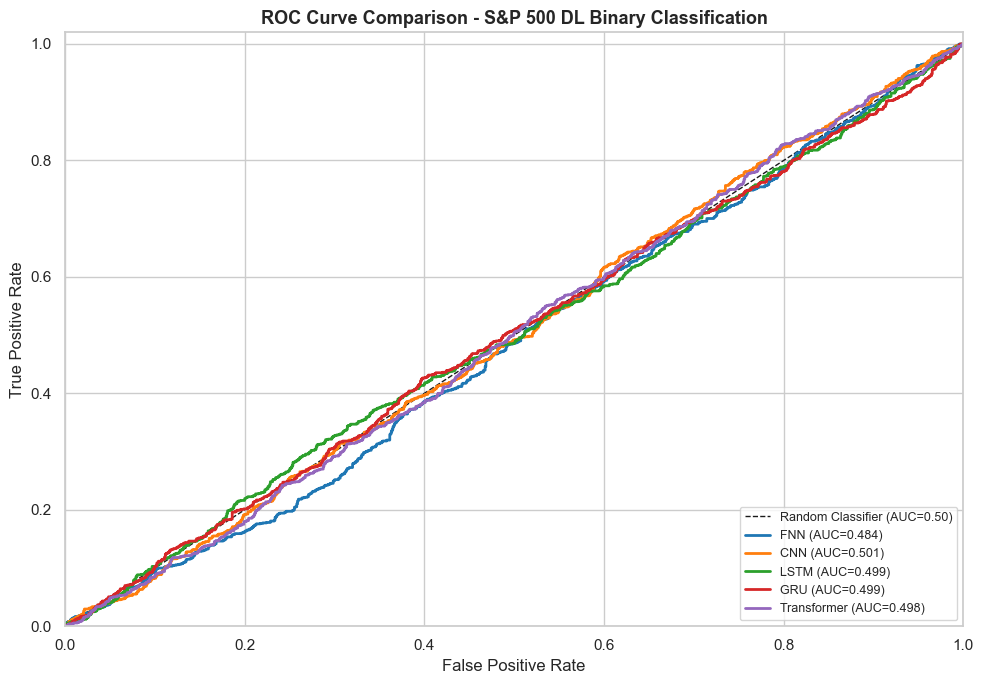

In [38]:
print('=' * 60)
print('=== STEP 8: ROC CURVE COMPARISON ===')
print('=' * 60)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier (AUC=0.50)')

colors = plt.cm.tab10.colors
for idx, (name, res) in enumerate(results.items()):
    _, y_te = model_test_data[name]
    fpr, tpr, _ = roc_curve(y_te, res['y_proba'])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[idx % 10], lw=2,
            label=f'{name} (AUC={auc_val:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison - S&P 500 DL Binary Classification',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'roc_curve_comparison_dl.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 9 - Overfitting Analysis

In [39]:
print('=' * 60)
print('=== STEP 9: OVERFITTING ANALYSIS ===')
print('=' * 60)

overfit_rows = []
base_models = {k: v for k, v in trained_models.items() if 'tuned' not in k}
for name, model in base_models.items():
    if name == 'FNN':        X_tr_m, y_tr_m = X_train,     y_train
    elif name == 'CNN':      X_tr_m, y_tr_m = X_train_cnn, y_train
    else:                    X_tr_m, y_tr_m = X_seq_train, y_seq_train
    _, y_te_m = model_test_data[name]
    y_tr_p   = model.predict(X_tr_m, verbose=0).flatten()
    y_te_p   = results[name]['y_proba']
    tr_acc   = accuracy_score(y_tr_m, (y_tr_p >= 0.5).astype(int))
    te_acc   = results[name]['Accuracy']
    tr_auc   = roc_auc_score(y_tr_m, y_tr_p)
    te_auc   = results[name]['ROC-AUC']
    gap      = tr_auc - te_auc
    status   = 'POTENTIALLY OVERFIT' if gap > 0.05 else 'OK'
    if gap > 0.05: print(f'WARNING: {name} AUC gap = {gap:.4f} ({status})')
    overfit_rows.append({'Model': name,
        'Train_Acc': round(tr_acc,4), 'Test_Acc': round(te_acc,4),
        'Train_AUC': round(tr_auc,4), 'Test_AUC': round(te_auc,4),
        'AUC_Gap': round(gap,4), 'Status': status})

overfit_df = pd.DataFrame(overfit_rows)
overfit_df.to_csv(os.path.join(output_dir, 'overfitting_analysis.csv'), index=False)
print('Saved: overfitting_analysis.csv')
display(overfit_df)

=== STEP 9: OVERFITTING ANALYSIS ===
Saved: overfitting_analysis.csv


,Model,Train_Acc,Test_Acc,Train_AUC,Test_AUC,AUC_Gap,Status
0,FNN,0.5281,0.4983,0.5452,0.4840,0.0611,POTENTIALLY OVERFIT
1,CNN,0.5125,0.5207,0.5044,0.5006,0.0038,OK
2,LSTM,0.5153,0.4938,0.5257,0.4994,0.0263,OK
3,GRU,0.5156,0.5042,0.5190,0.4988,0.0203,OK
4,Transformer,0.5199,0.5058,0.5233,0.4982,0.0251,OK


## Section 10 - Save Best Model

In [40]:
print('=' * 60)
print('=== STEP 10: SAVE BEST MODEL ===')
print('=' * 60)

# Pick best model across all (including tuned)
final_best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
final_best_auc  = results[final_best_name]['ROC-AUC']
final_best_f1   = results[final_best_name]['F1']
final_model_obj = trained_models[final_best_name]

# Save in Keras native format
model_path = os.path.join(output_dir, 'best_dl_model.keras')
final_model_obj.save(model_path)
print(f'Saved best model: {model_path}')

# Confirm scaler is present
scaler_path = os.path.join(output_dir, 'scaler.pkl')
if os.path.exists(scaler_path): print(f'Scaler confirmed: {scaler_path}')
else: print('WARNING: scaler.pkl not found!')

print(f'\n{"=" * 50}')
print('FINAL SUMMARY')
print(f'{"=" * 50}')
print(f'Best Model    : {final_best_name}')
print(f'Test ROC-AUC  : {final_best_auc:.4f}')
print(f'Test F1 Score : {final_best_f1:.4f}')
print(f'Saved at      : {os.path.abspath(model_path)}')

=== STEP 10: SAVE BEST MODEL ===
Saved best model: ..\..\output\best_dl_model.keras
Scaler confirmed: ..\..\output\scaler.pkl

FINAL SUMMARY
Best Model    : CNN
Test ROC-AUC  : 0.5006
Test F1 Score : 0.6835
Saved at      : e:\Python_projects\Coursera\deep_learning-badge\s_n_p_dl_classifier\model_files\output\best_dl_model.keras


## Key Findings and Insights

*(Populate after running the notebook with actual results.)*

### Model Performance Summary
- Best architecture: **[fill after run]**
- Best Test ROC-AUC: **[fill after run]**

### Artefacts Saved to `model_files/output/`
| File | Description |
|------|-------------|
| `processed_stocks.csv` | Cleaned dataset with binary target |
| `features_stocks.csv` | Feature-engineered dataset (26 features) |
| `X_train/test.csv` | Scaled feature matrices |
| `y_train/test.csv` | Binary target vectors |
| `scaler.pkl` | Fitted StandardScaler (required for inference) |
| `best_dl_model.keras` | Best trained DL model |
| `dl_model_comparison.csv` | All model metrics side-by-side |
| `tuning_results.csv` | Hyperparameter search results |
| `overfitting_analysis.csv` | Train vs Test AUC gap analysis |